In this ***.ipynb** file, I will illustrate:
- subplot notation in matplotlib
-  put multiple visualizations on the same axes objects
- show errors
- Adjust figure layout
- Add  images to plots

In [2]:
# Let me start as usual by loading the reuired libraries and generating some new sample data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

# generate some new sample data
np.random.seed(613)
x1  = np.arange(50)
y1 = np.random.randint(0, 75, 50)
x2 = np.array(['Luffy', 'Zoro',  'Nami', 'Usopp', 'Sanji'])
y2 = np.array([110, 180, 240, 99, 220])

### Introducing subplots
- In past  lessons, to define the figure and its one axes, I would type
```
     fig, ax  = plt.subplots(figsiez = (5,2))
```
-  Now I want to have two plots next too each other, so I jusr have tp define multiplee axes and their relative postions
```
      fig, (ax1, ax2)  = plt.subplots(ncols = 2,nrows = 1, figsize = (7,3))
```
-  Then, I can use the new figure, wth its two axes, and define the typles of the viz that i want to see each other

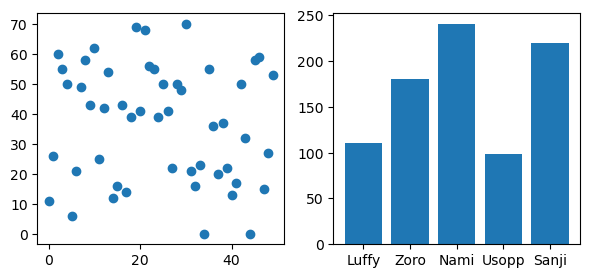

In [5]:
fig, (ax1, ax2)  = plt.subplots(ncols = 2,
                                nrows = 1, 
                                figsize = (7,3))
ax1.scatter(x1, y1)
ax2.bar(x2, y2)
plt.show()

# Activity: Customizing the plots
### Subplots without a grid  arrangement
-  I can also arrange the subplots within the figure by using **plt.subplot_mosic()**
- Each axes in the subplot_mosaic() function hhas a **"label"**

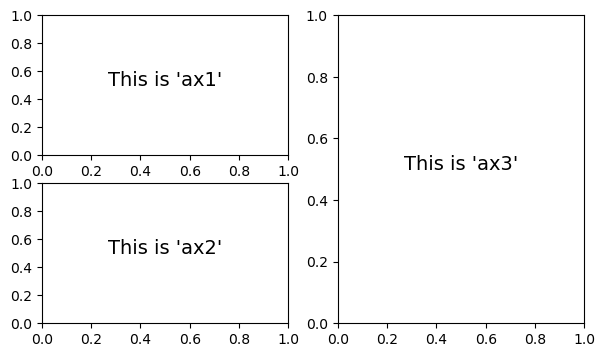

In [7]:
fig, someaxes =  plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize = (7,4))

for label, ax in someaxes.items():
    ax.text(0.5, 0.5, f'This is {label!r}',
            fontsize = 14,
            ha = 'center',
            transform = ax.transAxes)

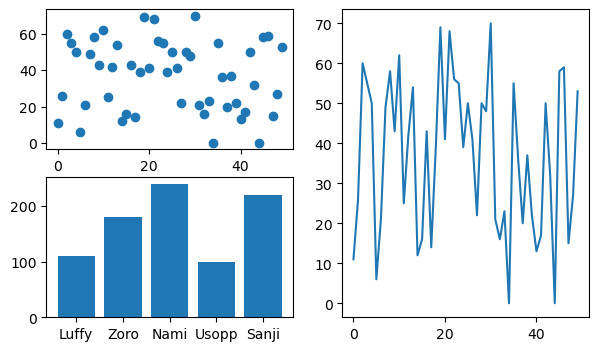

In [8]:
fig, someaxes =  plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize = (7,4))

someaxes['ax1'].scatter(x1,y1)
someaxes['ax2'].bar(x2,y2)
someaxes['ax3'].plot(x1,y1)
plt.show()

## Modifying figure layout
- Let's try adding some very large x titles to the previous plot

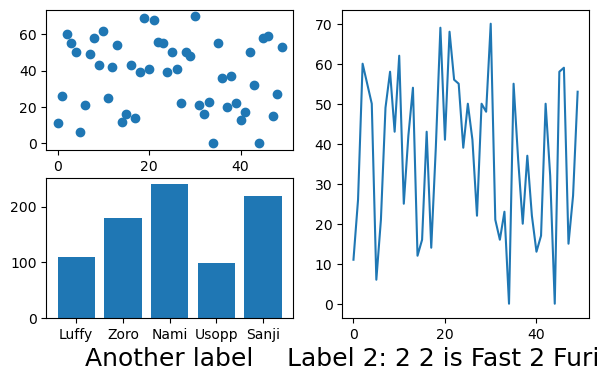

In [9]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize = (7,4))

someaxes['ax1'].scatter(x1,y1)
someaxes['ax2'].bar(x2,y2)
someaxes['ax3'].plot(x1,y1)
someaxes['ax1'].set_xlabel('A big label', fontsize = 18)
someaxes['ax2'].set_xlabel('Another label', fontsize = 18)
someaxes['ax3'].set_xlabel('Label 2: 2 2 is Fast 2 Furious', fontsize = 18)
plt.show()

# Layouts
- I can use layouts to make sure subplots fit neatly in our figure area
- There aretwo main kinds of layout I consider
  - **Tight layout** adjusts subplots so tick labels, axis labels, and titles don't overlap or leave the figre area
  - **Constrained layout** works similarly except it also fits things like legends or colorbars

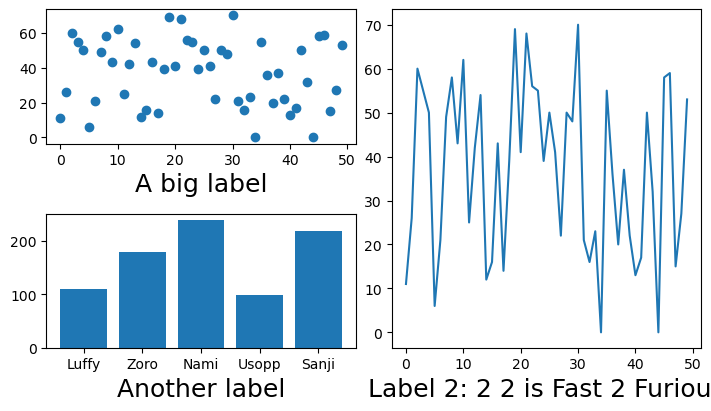

In [10]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize = (7,4), layout = 'constrained')

someaxes['ax1'].scatter(x1,y1)
someaxes['ax2'].bar(x2,y2)
someaxes['ax3'].plot(x1,y1)
someaxes['ax1'].set_xlabel('A big label', fontsize = 18)
someaxes['ax2'].set_xlabel('Another label', fontsize = 18)
someaxes['ax3'].set_xlabel('Label 2: 2 2 is Fast 2 Furious', fontsize = 18)
plt.show()

## Multiple vis on one axes object
- Super easy:  just call multiple plot methods on the same axes


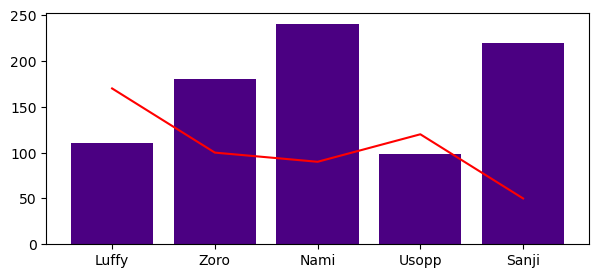

In [11]:
# first make the sample data
x = np.array(['Luffy', 'Zoro', 'Nami', 'Usopp', 'Sanji'])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

# Define the figure and axes (just one this time)
fig, ax = plt.subplots(figsize = (7,3))

# now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1, color = 'indigo')
ax.plot(x, y2, color = 'red')
plt.show()

## Adding error information

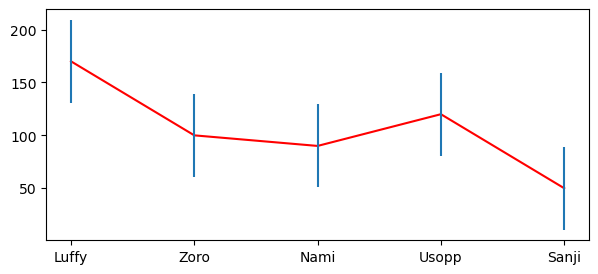

In [12]:
# First, calculate standard deviation of the data
y2_sd = np.std(y2)

# Then,  plot the line as before
fig, ax = plt.subplots(figsize = (7,3))
ax.plot(x, y2, color = 'red')

# Add error information
ax.errorbar(x, y2, yerr = y2_sd, fmt = 'none')

plt.show()

## Customize errorbar appearannce

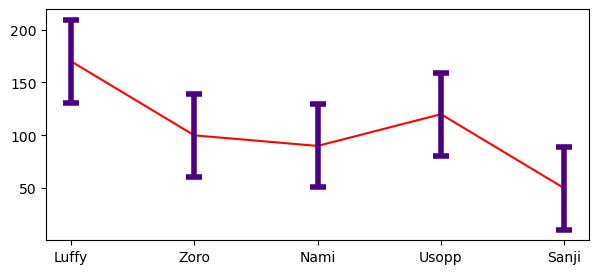

In [13]:
# First, calculate standard deviation of the data
y2_sd = np.std(y2)

# Then,  plot the line as before
fig, ax = plt.subplots(figsize = (7,3))
ax.plot(x, y2, color = 'red')

# Add error information
ax.errorbar(x, y2, yerr = y2_sd, fmt = 'none', ecolor = 'indigo', elinewidth = 4, capsize = 6, capthick = 4)

plt.show()

## Errorevery
- If I don't want to see error bars for every single point, I can specify intervals using errorevery

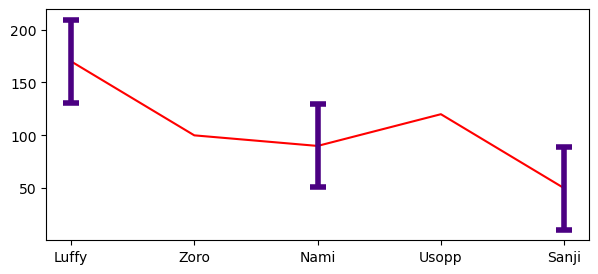

In [17]:
# First, calculate standard deviation of the data
y2_sd = np.std(y2)

# Then,  plot the line as before
fig, ax = plt.subplots(figsize = (7,3))
ax.plot(x, y2, color = 'red')

# Add error information
ax.errorbar(x, y2, yerr = y2_sd, fmt = 'none', ecolor = 'indigo', elinewidth = 4, capsize = 6, capthick = 4, errorevery = 2)

plt.show()

### Add images
- Using images from the internet
-  First let's load the required libraries for adding images
- Then, get the image from the internet

In [18]:
from PIL import Image # to open images
import requests # to get images from URLs
from io import BytesIO # to store images

response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png')
image_file = BytesIO(response.content)
image = Image.open(image_file)

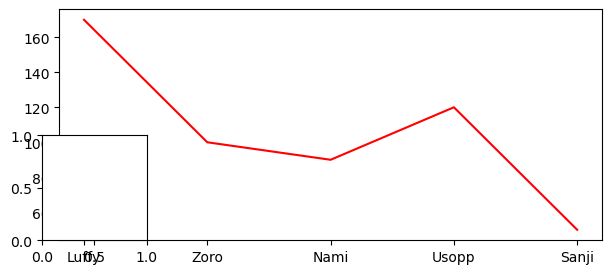

In [19]:
# Make a basic line plot (reuse the data)
fig, ax  = plt.subplots(figsize = (7,3))
ax.plot(x, y2, color = 'red')
# Then, overlay a new axis ('ax_iamge') on the figure (on top of 'ax') to act as a container for our image
ax_image = fig.add_axes([0.1,0.11, 0.15, 0.35])
plt.show()

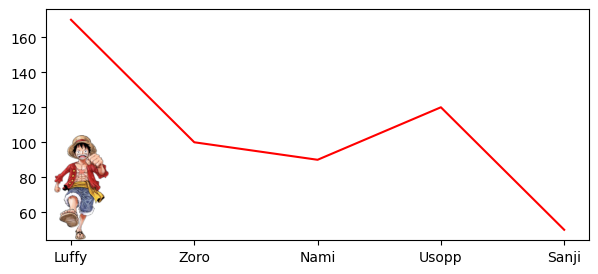

In [20]:
# Make a basic line plot (reuse the data)
fig, ax  = plt.subplots(figsize = (7,3))
ax.plot(x, y2, color = 'red')
# Then, overlay a new axis ('ax_iamge') on the figure (on top of 'ax') to act as a container for our image
ax_image = fig.add_axes([0.1,0.11, 0.15, 0.35])
ax_image.imshow(image)
ax_image.axis('off')
plt.show()